In [1]:
PRODUCTION_QUALITY = False

import ipdb
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import seaborn as sns
import pandas as pd
import os
import re
import warnings

from itertools import cycle
from labellines import labelLines

plt.style.use(['science', 'bright'])

dpi = 300 if PRODUCTION_QUALITY else 100

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 12,
    'font.family': 'lmodern',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'savefig.dpi': dpi,
})

EXPERIMENT_BASE='16-weight-perturbation'

# Beamer 16:9
WIDTH=455.24408

#WIDTH=441.01775
OUTPUT_DIR=f'../{EXPERIMENT_BASE}/images'

os.makedirs(OUTPUT_DIR, exist_ok=True) # make sure it exists

# image saving format
IMG_FORMAT = 'png'

# Mapping of full model names to abbreviations
MODEL_NAME_MAP = {
    'vit_base_patch16_224.augreg_in21k': 'ViT',
    'resnetv2_50x1_bit.goog_in21k': 'ResNetV2',
}

N_BOOTSTRAP_SAMPLES=100

In [2]:
def set_size(width_pt, fraction=1, subplots=(1, 1), y_scale=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    
    if y_scale:
        fig_height_in = fig_height_in * y_scale

    return (fig_width_in, fig_height_in)

In [3]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    figsize = set_size(WIDTH, fraction=fraction, subplots=subplots, y_scale=y_scale)
    fig, axes = plt.subplots(subplots[0], subplots[1], figsize=figsize, constrained_layout=True)

    return fig, axes

In [4]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [5]:
def prepare_data(data):
    records = []
    for experiment_details in data:
        # Extracting values from the JSON structure
        subset_size = experiment_details['configuration']['subset_size']
        weight_perturbation_level = experiment_details['configuration']['weight_perturbation_level']
        max_grad_norm = experiment_details['hyperparameters']['max_grad_norm']
        epochs = experiment_details['hyperparameters']['epochs']
                    
        learning_rate = experiment_details['best_params']['learning_rate']
        batch_size = experiment_details['best_params']['batch_size']

        # Handling the full batch size case
        if batch_size == -1:
            full_batch_size = 7500 if subset_size == 0.1 else 7500
            batch_size = full_batch_size

        record = {
            'runtime': experiment_details['runtime'],
            'model_name': experiment_details['configuration']['model_name'],
            'dataset_name': experiment_details['configuration']['dataset_name'],
            'subset_size': subset_size,
            'weight_perturbation_level': weight_perturbation_level,
            'epsilon': experiment_details['hyperparameters']['target_epsilon'],
            'max_grad_norm': max_grad_norm,
            'accuracy': float(experiment_details['best_value']),
            'learning_rate': learning_rate,
            'batch_size': batch_size,
            'epochs': epochs,
        }

        # Add final metrics also
        for metric_name, metric_value in experiment_details['final_metrics'].items():
            record[metric_name] = metric_value

        records.append(record)

    df = pd.DataFrame(records)

    df['runtime_seconds'] = pd.to_timedelta(df['runtime']).dt.total_seconds()

    return df


# Accuracy trends by noise level

In [18]:
def plot_accuracy_trends(prepared_data, output_dir=None, min_grad_norm=0):
    # Sort values
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'weight_perturbation_level', 'max_grad_norm', 'epochs'], inplace=True)
    
    # Group by model, dataset, subset size, and epsilon
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'epochs'])

    # Get SciencePlots colors
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    color_cycle = cycle(colors)  # Cycle through the colors

    for (model, dataset, subset, epsilon, epochs), group in groups:
        fig, ax = get_figure((1, 1), fraction=1.5)
        model_name = MODEL_NAME_MAP.get(model, model)

        # Use the color cycle for this axis
        ax.set_prop_cycle('color', colors)

        # Group by weight_perturbation_level to plot all levels in the same plot
        grouped_by_weight = group.groupby('weight_perturbation_level')

        for weight_perturbation_level, weight_data in grouped_by_weight:
            color = next(color_cycle)  # Next color
            weight_data = weight_data.sort_values(by='max_grad_norm')

            grad_norm_grouped = weight_data.groupby('max_grad_norm')
            mean_accuracy = []
            grad_norms = []

            for grad_norm, grad_group in grad_norm_grouped:
                # Skip grad_norm values smaller than min grad norm
                if grad_norm < min_grad_norm:
                    continue

                mean_accuracy.append(grad_group['MulticlassAccuracy'].mean())
                grad_norms.append(grad_norm)

            ax.plot(grad_norms, mean_accuracy, label=f'Weight Perturbation {weight_perturbation_level:.3f}', marker='o', linestyle='-', color=color)

        ax.set_title(f'Accuracy Trends for {model_name} on {dataset} ({int(subset*100)}\% Subset, $\epsilon={epsilon}$, {epochs} Epochs)')        
        ax.set_xlabel('Clipping Bound')
        ax.set_ylabel('Accuracy')
        ax.set_xscale('log')

        # Set x-ticks labels
        all_grad_norms = group['max_grad_norm'].unique()

        if min_grad_norm is not None:
            all_grad_norms = [gn for gn in all_grad_norms if gn >= min_grad_norm]

        all_grad_norms.sort()

        ax.set_xticks(all_grad_norms)
        ax.set_xticklabels([f'{x:.5f}' for x in all_grad_norms], rotation=45)

        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        ax.grid(True)

        # Save plot
        if output_dir:
            safe_dataset_name = dataset.split('/')[-1]
            plt.savefig(os.path.join(output_dir, f'clipping_bound_accuracy_trends_zoomed_{model_name}_{safe_dataset_name}_subset{subset}_epsilon{epsilon}_epochs{epochs}.{IMG_FORMAT}'), bbox_inches='tight')

        plt.show()

In [19]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_accuracy_trends(processed_data, output_dir=OUTPUT_DIR, min_grad_norm=1)
    #plot_accuracy_trends(processed_data, output_dir=OUTPUT_DIR)

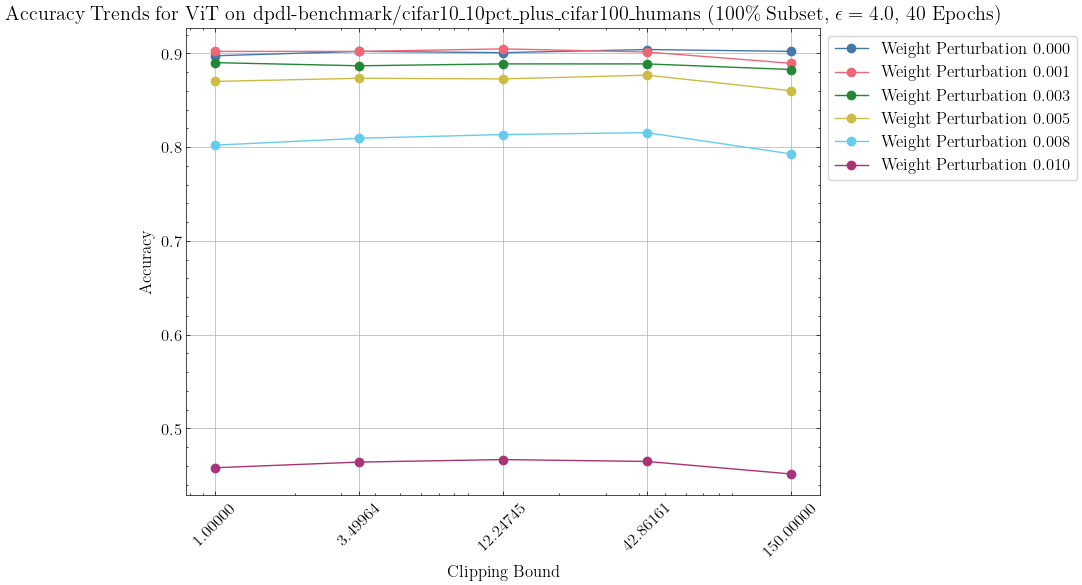

In [20]:
plot()

# Acccuracy trends by noise level - relative differences

In [21]:
def plot_accuracy_trends_relative_differences(prepared_data, output_dir=None, min_grad_norm=0):
    # Sort values
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'weight_perturbation_level', 'max_grad_norm', 'epochs'], inplace=True)
    
    # Filter out too small clipping bounds
    prepared_data = prepared_data[prepared_data['max_grad_norm'] >= min_grad_norm]

    # Group the data for plotting
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'epochs'])

    # Get SciencePlots colors
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    color_cycle = cycle(colors)

    for (model, dataset, subset, epsilon, epochs), group in groups:
        fig, ax = get_figure((1, 1), fraction=1.5)
        model_name = MODEL_NAME_MAP.get(model, model)

        # Use the color cyle
        ax.set_prop_cycle('color', colors)

        # Group by weight_perturbation_level to plot all levels in the same plot
        grouped_by_weight = group.groupby('weight_perturbation_level')

        # Store the accuracies per grad norm and the best value here
        # in order to calculate the relative differences
        accuracy_data = {}

        # Loop through weight perturbation levels to calculate differences from the best
        for weight_perturbation_level, weight_data in grouped_by_weight:
            weight_data = weight_data.sort_values(by='max_grad_norm')
            grad_norm_grouped = weight_data.groupby('max_grad_norm')

            for grad_norm, grad_group in grad_norm_grouped:
                mean_accuracy = grad_group['MulticlassAccuracy'].mean()

                # Store the accuracies
                if grad_norm not in accuracy_data:
                    accuracy_data[grad_norm] = {}
    
                accuracy_data[grad_norm][weight_perturbation_level] = mean_accuracy

        # Plot the difference from the best accuracy
        for weight_perturbation_level, weight_data in grouped_by_weight:
            color = next(color_cycle)  # Get the next color from the cycle
            weight_data = weight_data.sort_values(by='max_grad_norm')

            grad_norm_grouped = weight_data.groupby('max_grad_norm')
            accuracy_differences = []
            grad_norms = []

            for grad_norm, grad_group in grad_norm_grouped:
                mean_accuracy = grad_group['MulticlassAccuracy'].mean()

                # Calculate the difference from the best accuracy for this grad_norm
                best_accuracy = max(accuracy_data[grad_norm].values())
                accuracy_differences.append(mean_accuracy - best_accuracy)
                grad_norms.append(grad_norm)

            ax.plot(grad_norms, accuracy_differences, label=f'Weight Perturbation {weight_perturbation_level:.3f}', marker='o', linestyle='-', color=color)

        ax.set_title(f'Accuracy Differences for {model_name} on {dataset} ({int(subset*100)}\% Subset, $\epsilon={epsilon}$, {epochs} Epochs)')        
        ax.set_xlabel('Clipping Bound')
        ax.set_ylabel('Accuracy Difference from Best')
        ax.set_xscale('log')

        # Set xtick labels
        unique_grad_norms = np.unique(group['max_grad_norm'])
        ax.set_xticks(unique_grad_norms)
        ax.set_xticklabels([f'{x:.5f}' for x in unique_grad_norms], rotation=45)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        ax.grid(True)

        # Save plot
        if output_dir:
            safe_dataset_name = dataset.split('/')[-1]
            plt.savefig(os.path.join(output_dir, f'clipping_bound_accuracy_diff_from_best_{model_name}_{safe_dataset_name}_subset{subset}_epsilon{epsilon}_epochs{epochs}.{IMG_FORMAT}'), bbox_inches='tight')

        plt.show()

In [22]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_accuracy_trends_relative_differences(processed_data, output_dir=OUTPUT_DIR, min_grad_norm=1)
    #lot_accuracy_trends_relative_differences(processed_data, output_dir=OUTPUT_DIR)

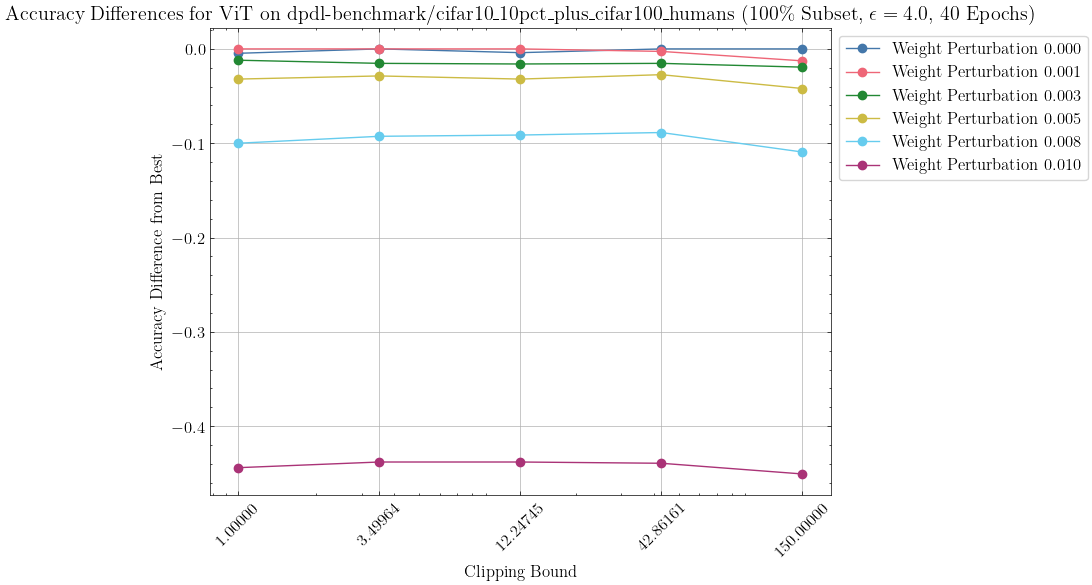

In [23]:
plot()

# Accuracy trends - one line per plot

In [24]:
def plot_accuracy_trends_multiple(prepared_data, output_dir=None, min_grad_norm=0, y_margin=0.001):
    # Sort values
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'weight_perturbation_level', 'max_grad_norm', 'epochs'], inplace=True)
    
    # Group by model, dataset, subset size, and epsilon
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'epochs'])

    # Get SciencePlots colors
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    color_cycle = cycle(colors)  # Cycle through these colors

    # Calculate the global min and max accuracy across all data points
    # NB: Trying to find a good y-axis range for the plots here
    global_min_accuracy = float('inf')
    global_max_accuracy = float('-inf')

    for (model, dataset, subset, epsilon, epochs), group in groups:
        grouped_by_weight = group.groupby('weight_perturbation_level')
        for weight_perturbation_level, weight_data in grouped_by_weight:
            weight_data = weight_data.sort_values(by='max_grad_norm')

            grad_norm_grouped = weight_data.groupby('max_grad_norm')
            for grad_norm, grad_group in grad_norm_grouped:
                mean_accuracy = grad_group['MulticlassAccuracy'].mean()
                global_min_accuracy = min(global_min_accuracy, mean_accuracy)
                global_max_accuracy = max(global_max_accuracy, mean_accuracy)

    # Calculate the global y-range and add margin
    global_y_range = global_max_accuracy - global_min_accuracy
    y_buffer = y_margin * global_y_range

    # Plot each weight perturbation level in a separate plot
    for (model, dataset, subset, epsilon, epochs), group in groups:
        model_name = MODEL_NAME_MAP.get(model, model)

        # Group by weight_perturbation_level to plot each level in its own plot
        grouped_by_weight = group.groupby('weight_perturbation_level')

        for weight_perturbation_level, weight_data in grouped_by_weight:
            fig, ax = get_figure((1, 1), fraction=1.5)
            color = next(color_cycle)
            weight_data = weight_data.sort_values(by='max_grad_norm')

            grad_norm_grouped = weight_data.groupby('max_grad_norm')
            mean_accuracy = []
            grad_norms = []

            for grad_norm, grad_group in grad_norm_grouped:
                # Skip grad_norm values smaller than min
                if grad_norm < min_grad_norm:
                    continue

                mean_accuracy.append(grad_group['MulticlassAccuracy'].mean())
                grad_norms.append(grad_norm)

            # Plot this weight perturbation level
            ax.plot(grad_norms, mean_accuracy, label=f'Weight Perturbation {weight_perturbation_level:.3f}', marker='o', linestyle='-', color=color)

            # Get the local min and max accuracy values for this line
            local_min = min(mean_accuracy)
            local_max = max(mean_accuracy)
            local_range = local_max - local_min

            # Use a consistent y-range, centered around local data, but respecting global y-buffer
            y_min = max(local_min - y_buffer, global_min_accuracy - y_buffer)
            y_max = min(local_max + y_buffer, global_max_accuracy + y_buffer)
            ax.set_ylim(y_min, y_max)

            ax.set_title(f'Accuracy Trends for {model_name} on {dataset} ({int(subset*100)}\% Subset, $\epsilon={epsilon}$, {epochs} Epochs, Weight Perturbation {weight_perturbation_level:.3f})')
            ax.set_xlabel('Clipping Bound')
            ax.set_ylabel('Accuracy')
            ax.set_xscale('log')

            # Set xtick labels
            all_grad_norms = group['max_grad_norm'].unique()

            # Filter grad_norms based on min_grad_norm
            if min_grad_norm is not None:
                all_grad_norms = [gn for gn in all_grad_norms if gn >= min_grad_norm]
            all_grad_norms.sort()

            ax.set_xticks(all_grad_norms)
            ax.set_xticklabels([f'{x:.5f}' for x in all_grad_norms], rotation=45)
            ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
            ax.grid(True)

            # Save plot if output_dir is provided
            if output_dir:
                safe_dataset_name = dataset.split('/')[-1]
                plt.savefig(os.path.join(output_dir, f'separate_plot_accuracy_trends_{model_name}_{safe_dataset_name}_subset{subset}_epsilon{epsilon}_weight{weight_perturbation_level:.3f}_epochs{epochs}.{IMG_FORMAT}'), bbox_inches='tight')

            plt.show()


In [12]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    #plot_accuracy_trends_multiple(processed_data, output_dir=OUTPUT_DIR, min_grad_norm=1)
    plot_accuracy_trends_multiple(processed_data, output_dir=OUTPUT_DIR)

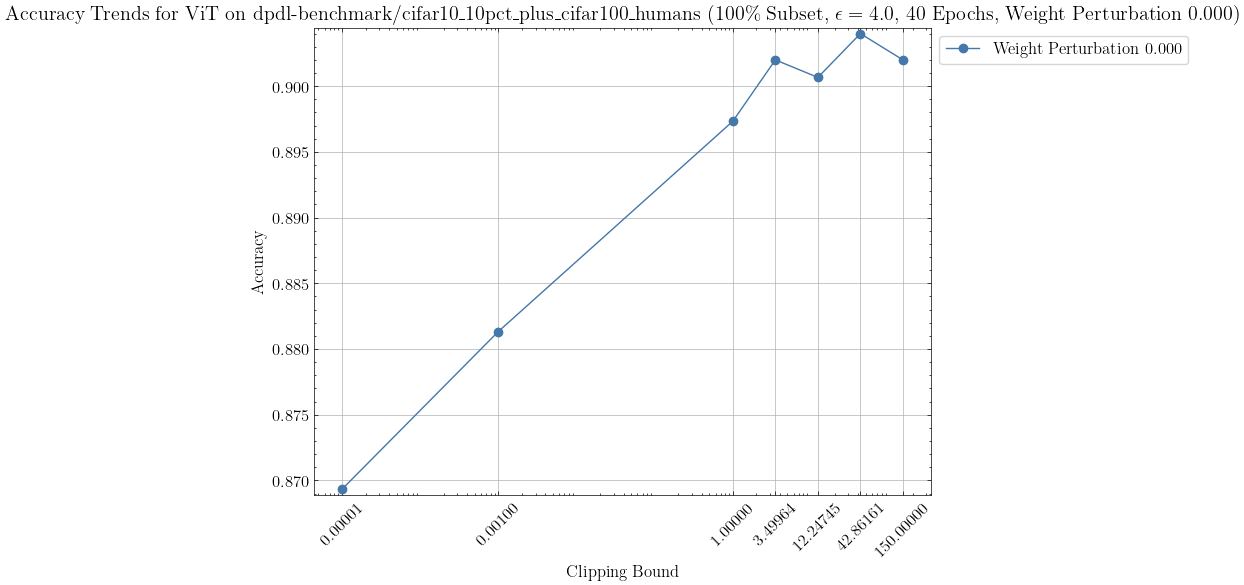

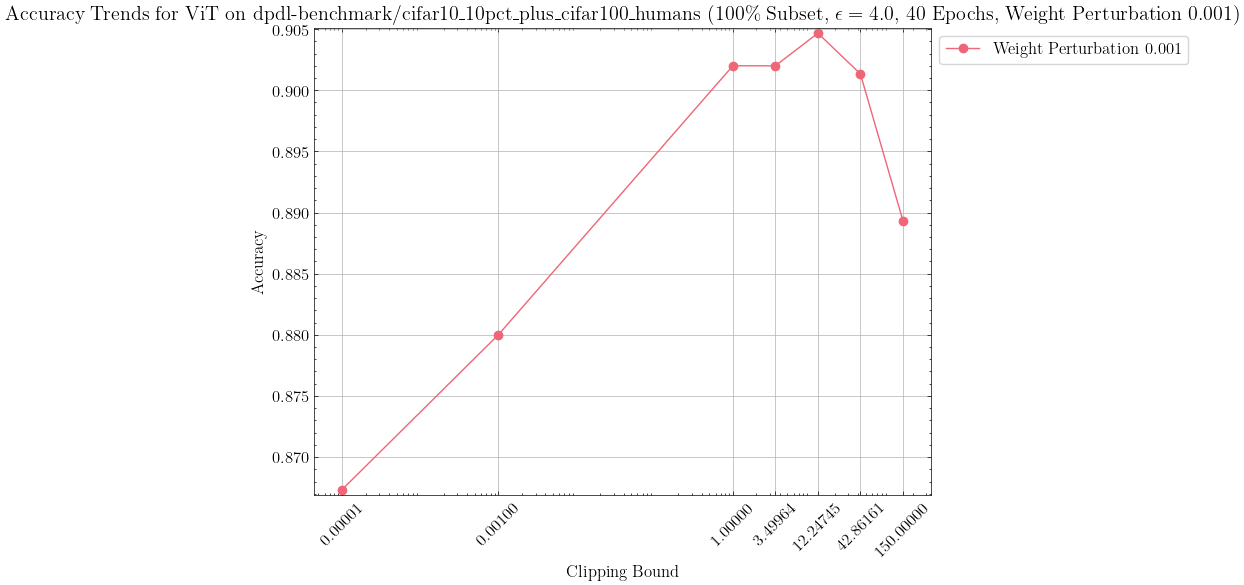

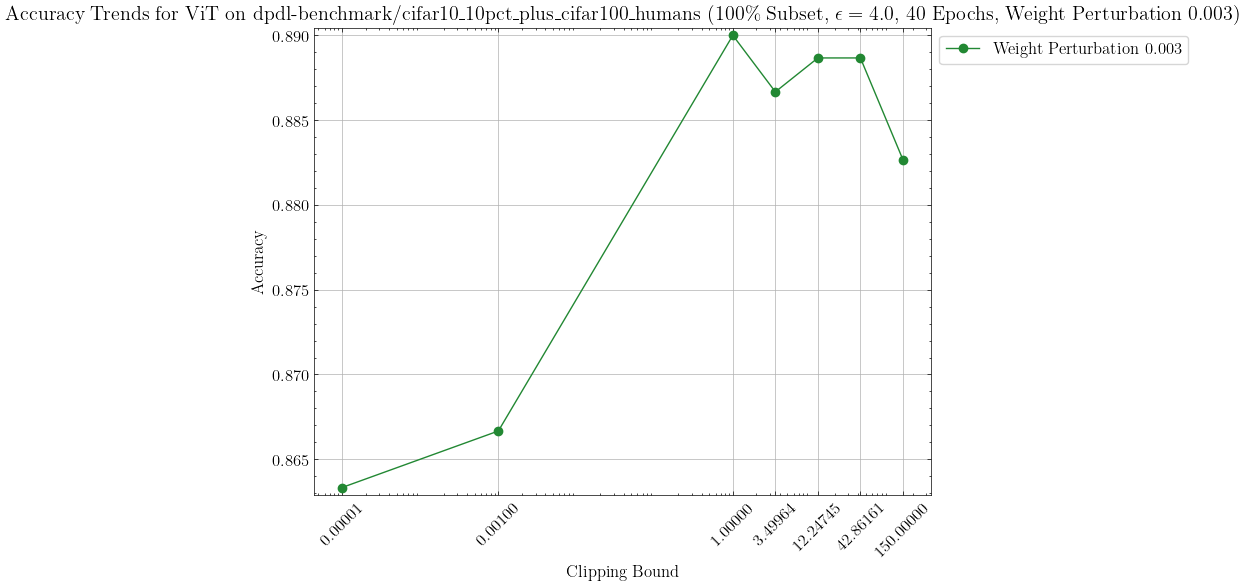

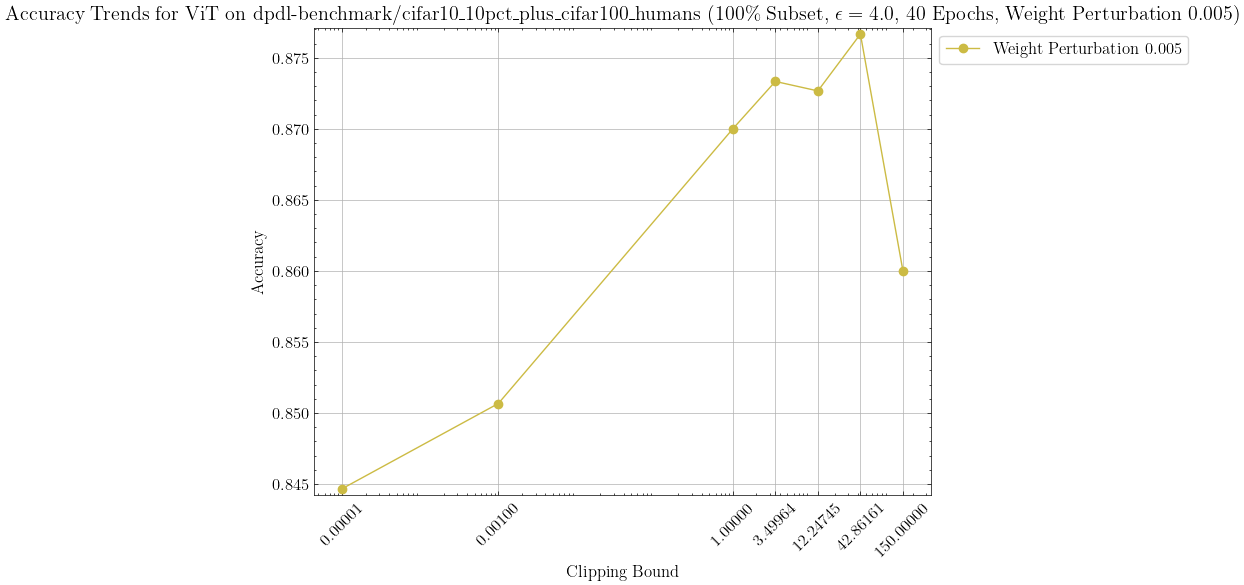

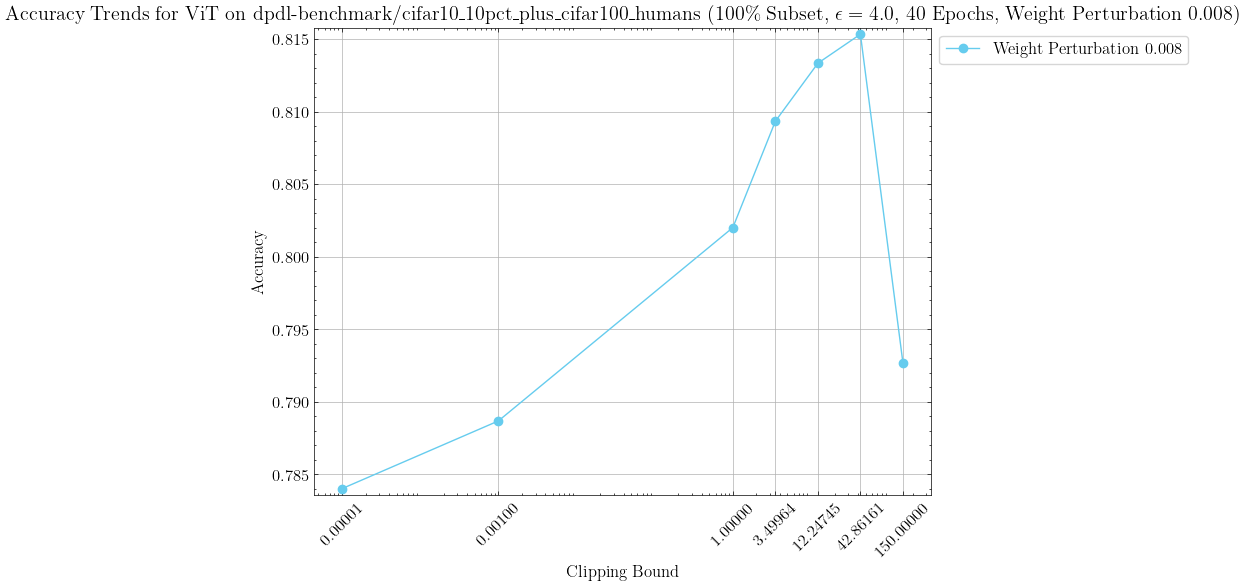

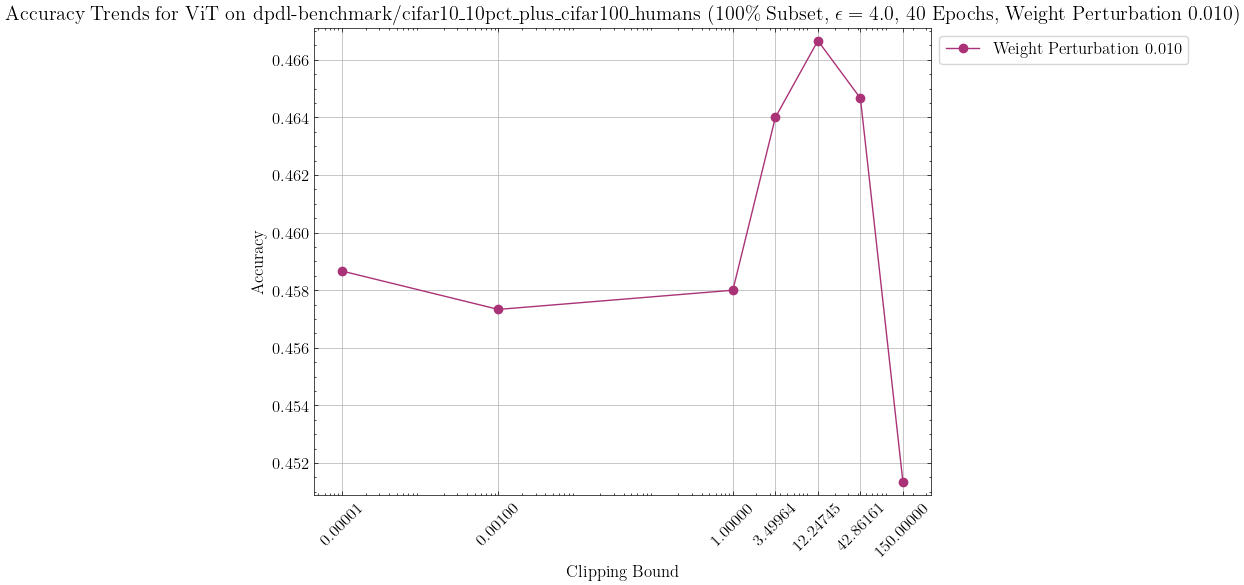

In [13]:
plot()